In [1]:
# Imports and settings initialization
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import plotly
import plotly.express as px
import plotly.io as pio
from plotly.offline import init_notebook_mode
import re
import nltk
from nltk.corpus import stopwords
from tqdm import tqdm
from nltk.stem import WordNetLemmatizer
import spacy
from textblob import TextBlob

tqdm.pandas()
spacy_eng = spacy.load("en_core_web_sm")
nltk.download('stopwords')
nltk.download('wordnet')
init_notebook_mode(connected=True)
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (20,8)
plt.rcParams['font.size'] = 18
plotly.offline.init_notebook_mode(connected=True)
# Ensure Plotly is properly configured for Colab
pio.renderers.default = "colab"

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [3]:
# Loading datasets
data1 = pd.read_json('Sarcasm_Headlines_Dataset.json', lines=True)
data2 = pd.read_json('Sarcasm_Headlines_Dataset_v2.json', lines=True)

In [4]:
#
data1

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0
...,...,...,...
26704,https://www.huffingtonpost.com/entry/american-...,american politics in moral free-fall,0
26705,https://www.huffingtonpost.com/entry/americas-...,america's best 20 hikes,0
26706,https://www.huffingtonpost.com/entry/reparatio...,reparations and obama,0
26707,https://www.huffingtonpost.com/entry/israeli-b...,israeli ban targeting boycott supporters raise...,0


<Axes: title={'center': 'is_sarcastic'}, ylabel='Frequency'>

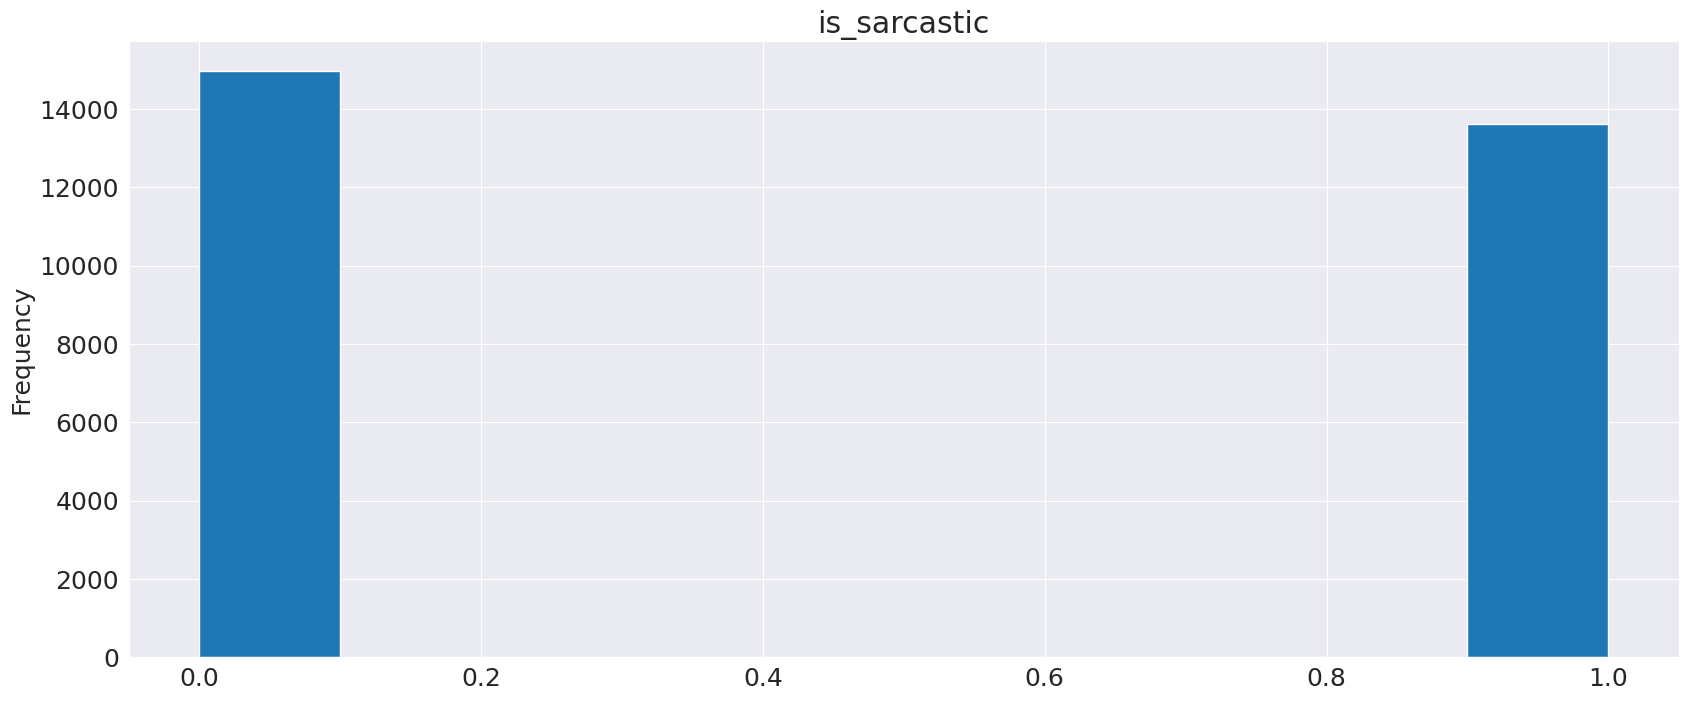

In [ ]:
# @title is_sarcastic

data1['is_sarcastic'].plot(kind='hist', bins=10, title='is_sarcastic')

In [5]:
#
data2

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...
...,...,...,...
28614,1,jews to celebrate rosh hashasha or something,https://www.theonion.com/jews-to-celebrate-ros...
28615,1,internal affairs investigator disappointed con...,https://local.theonion.com/internal-affairs-in...
28616,0,the most beautiful acceptance speech this week...,https://www.huffingtonpost.com/entry/andrew-ah...
28617,1,mars probe destroyed by orbiting spielberg-gat...,https://www.theonion.com/mars-probe-destroyed-...


<Axes: title={'center': 'is_sarcastic'}, ylabel='Frequency'>

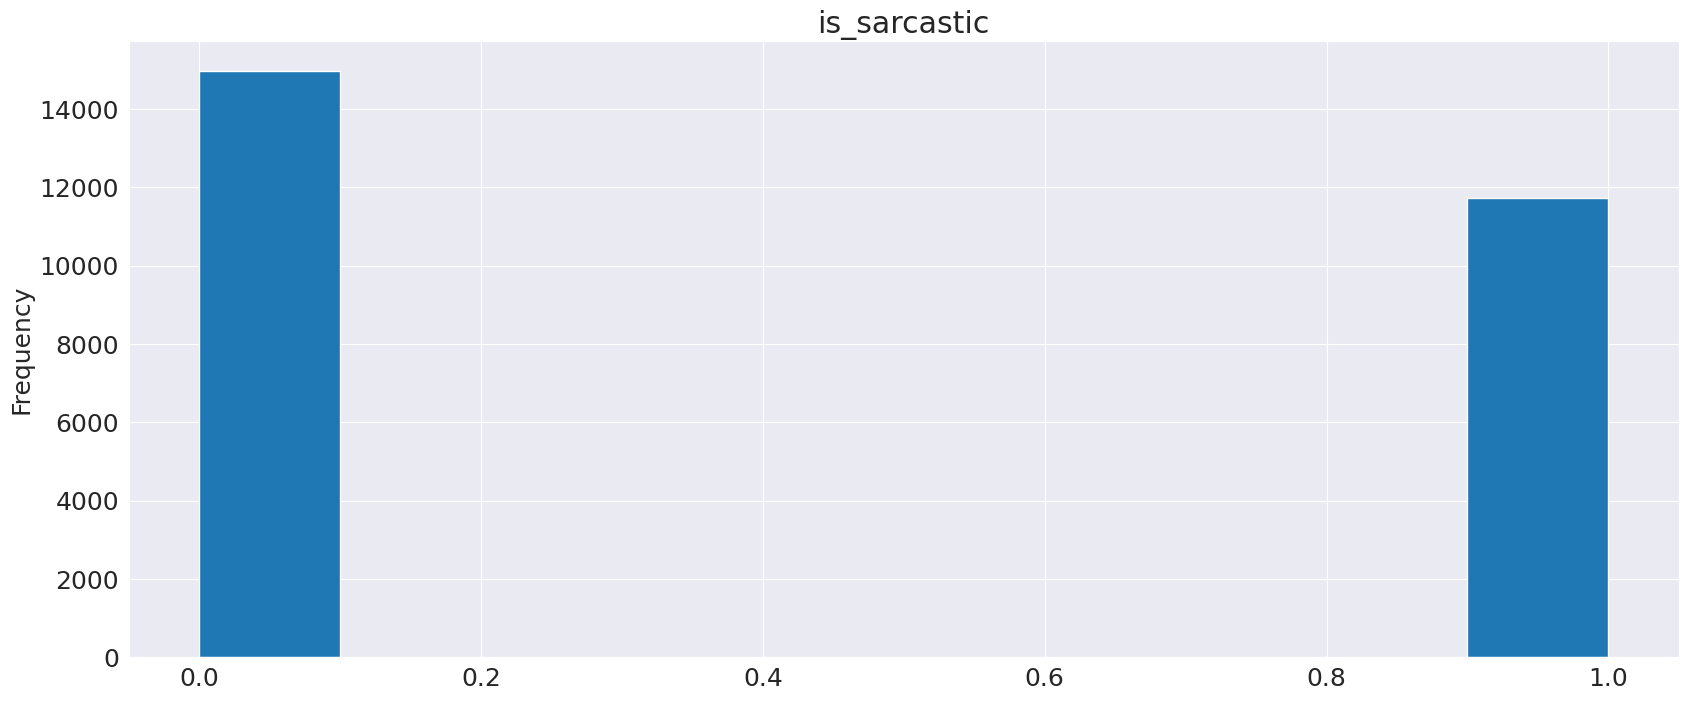

In [6]:
#
data2['is_sarcastic'].plot(kind='hist', bins=10, title='is_sarcastic')


**Merge the two datasets**

In [6]:

data = pd.concat([data1,data2])
data.reset_index(drop=True, inplace=True)

In [15]:
data

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0
...,...,...,...
55323,https://www.theonion.com/jews-to-celebrate-ros...,jews to celebrate rosh hashasha or something,1
55324,https://local.theonion.com/internal-affairs-in...,internal affairs investigator disappointed con...,1
55325,https://www.huffingtonpost.com/entry/andrew-ah...,the most beautiful acceptance speech this week...,0
55326,https://www.theonion.com/mars-probe-destroyed-...,mars probe destroyed by orbiting spielberg-gat...,1


**Drop article_link**

In [7]:
#
data = data[['headline','is_sarcastic']]
data

,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0
...,...,...
55323,jews to celebrate rosh hashasha or something,1
55324,internal affairs investigator disappointed con...,1
55325,the most beautiful acceptance speech this week...,0
55326,mars probe destroyed by orbiting spielberg-gat...,1


# EDA and Text Preprocessing

## Checking for Missing Values

In [8]:
data.isnull().sum()

headline        0
is_sarcastic    0
dtype: int64

## Finding the Classes Balance/Imbalance

In [9]:
# Group by 'is_sarcastic' and count occurrences
px.bar(data.groupby('is_sarcastic').count().reset_index(), x='headline', title='Count of Sarcastic and Genuine Headlines')


## Text Cleaning, Special Characters Removal & Lemmatization

In [10]:
stop_words = stopwords.words('english')
stop_words.remove('not')
lemm = WordNetLemmatizer()

def text_cleaning(headline):

    headline = re.sub('\s+\n+', ' ', headline)        # Remove sequences of whitespace and newlines
    headline = re.sub('[^a-zA-Z0-9]', ' ', headline)  # Remove non-alphanumeric characters
    headline = headline.lower()                       # Convert to lowercase
    headline = headline.split()                       # Split into words
    headline = [lemm.lemmatize(word, "v") for word in headline if not word in stop_words] # Remove stop words and lemmatize
    headline = ' '.join(headline)

    return headline

**Extracting clean_headline from headline**


In [11]:
data['clean_headline'] = data['headline'].apply(text_cleaning)
data

,headline,is_sarcastic,clean_headline
0,former versace store clerk sues over secret 'b...,0,former versace store clerk sue secret black co...
1,the 'roseanne' revival catches up to our thorn...,0,roseanne revival catch thorny political mood b...
2,mom starting to fear son's web series closest ...,1,mom start fear son web series closest thing gr...
3,"boehner just wants wife to listen, not come up...",1,boehner want wife listen not come alternative ...
4,j.k. rowling wishes snape happy birthday in th...,0,j k rowling wish snape happy birthday magical way
...,...,...,...
55323,jews to celebrate rosh hashasha or something,1,jews celebrate rosh hashasha something
55324,internal affairs investigator disappointed con...,1,internal affairs investigator disappoint consp...
55325,the most beautiful acceptance speech this week...,0,beautiful acceptance speech week come queer ko...
55326,mars probe destroyed by orbiting spielberg-gat...,1,mar probe destroy orbit spielberg gate space p...


**Extracting char_count from clean_headline**


In [22]:
data['char_count'] = data['clean_headline'].apply(len)
data

,headline,is_sarcastic,clean_headline,char_count
0,former versace store clerk sues over secret 'b...,0,former versace store clerk sue secret black co...,66
1,the 'roseanne' revival catches up to our thorn...,0,roseanne revival catch thorny political mood b...,57
2,mom starting to fear son's web series closest ...,1,mom start fear son web series closest thing gr...,54
3,"boehner just wants wife to listen, not come up...",1,boehner want wife listen not come alternative ...,66
4,j.k. rowling wishes snape happy birthday in th...,0,j k rowling wish snape happy birthday magical way,49
...,...,...,...,...
55323,jews to celebrate rosh hashasha or something,1,jews celebrate rosh hashasha something,38
55324,internal affairs investigator disappointed con...,1,internal affairs investigator disappoint consp...,62
55325,the most beautiful acceptance speech this week...,0,beautiful acceptance speech week come queer ko...,50
55326,mars probe destroyed by orbiting spielberg-gat...,1,mar probe destroy orbit spielberg gate space p...,51


**Extracting word_count from clean_headline**

In [23]:
data['word_count'] = data['clean_headline'].apply(lambda x: len(x.split()))
data

,headline,is_sarcastic,clean_headline,char_count,word_count
0,former versace store clerk sues over secret 'b...,0,former versace store clerk sue secret black co...,66,10
1,the 'roseanne' revival catches up to our thorn...,0,roseanne revival catch thorny political mood b...,57,8
2,mom starting to fear son's web series closest ...,1,mom start fear son web series closest thing gr...,54,9
3,"boehner just wants wife to listen, not come up...",1,boehner want wife listen not come alternative ...,66,10
4,j.k. rowling wishes snape happy birthday in th...,0,j k rowling wish snape happy birthday magical way,49,9
...,...,...,...,...,...
55323,jews to celebrate rosh hashasha or something,1,jews celebrate rosh hashasha something,38,5
55324,internal affairs investigator disappointed con...,1,internal affairs investigator disappoint consp...,62,8
55325,the most beautiful acceptance speech this week...,0,beautiful acceptance speech week come queer ko...,50,7
55326,mars probe destroyed by orbiting spielberg-gat...,1,mar probe destroy orbit spielberg gate space p...,51,8


**Extracting avg_word_length from clean_headline**

In [24]:
data['avg_word_length'] = data['clean_headline'].apply(lambda x: np.mean([len(word) for word in x.split()]))
data

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning:

Mean of empty slice.



,headline,is_sarcastic,clean_headline,char_count,word_count,avg_word_length
0,former versace store clerk sues over secret 'b...,0,former versace store clerk sue secret black co...,66,10,5.700000
1,the 'roseanne' revival catches up to our thorn...,0,roseanne revival catch thorny political mood b...,57,8,6.250000
2,mom starting to fear son's web series closest ...,1,mom start fear son web series closest thing gr...,54,9,5.111111
3,"boehner just wants wife to listen, not come up...",1,boehner want wife listen not come alternative ...,66,10,5.700000
4,j.k. rowling wishes snape happy birthday in th...,0,j k rowling wish snape happy birthday magical way,49,9,4.555556
...,...,...,...,...,...,...
55323,jews to celebrate rosh hashasha or something,1,jews celebrate rosh hashasha something,38,5,6.800000
55324,internal affairs investigator disappointed con...,1,internal affairs investigator disappoint consp...,62,8,6.875000
55325,the most beautiful acceptance speech this week...,0,beautiful acceptance speech week come queer ko...,50,7,6.285714
55326,mars probe destroyed by orbiting spielberg-gat...,1,mar probe destroy orbit spielberg gate space p...,51,8,5.500000


**Extracting sentiment from headline**

In [25]:
data['sentiment'] = data['headline'].apply(lambda x: TextBlob(x).sentiment.polarity)
data

,headline,is_sarcastic,clean_headline,char_count,word_count,avg_word_length,sentiment
0,former versace store clerk sues over secret 'b...,0,former versace store clerk sue secret black co...,66,10,5.700000,-0.188889
1,the 'roseanne' revival catches up to our thorn...,0,roseanne revival catch thorny political mood b...,57,8,6.250000,0.033333
2,mom starting to fear son's web series closest ...,1,mom start fear son web series closest thing gr...,54,9,5.111111,0.000000
3,"boehner just wants wife to listen, not come up...",1,boehner want wife listen not come alternative ...,66,10,5.700000,0.200000
4,j.k. rowling wishes snape happy birthday in th...,0,j k rowling wish snape happy birthday magical way,49,9,4.555556,0.600000
...,...,...,...,...,...,...,...
55323,jews to celebrate rosh hashasha or something,1,jews celebrate rosh hashasha something,38,5,6.800000,0.000000
55324,internal affairs investigator disappointed con...,1,internal affairs investigator disappoint consp...,62,8,6.875000,-0.083333
55325,the most beautiful acceptance speech this week...,0,beautiful acceptance speech week come queer ko...,50,7,6.285714,0.675000
55326,mars probe destroyed by orbiting spielberg-gat...,1,mar probe destroy orbit spielberg gate space p...,51,8,5.500000,0.000000


# Word Visualization: Word Clouds

In [26]:
sarcastic_sentences = data[data['is_sarcastic']==1]['clean_headline'].tolist()
genuine_sentences = data[data['is_sarcastic']==0]['clean_headline'].tolist()

**Top 100 Words: Sarcastic Headlines**



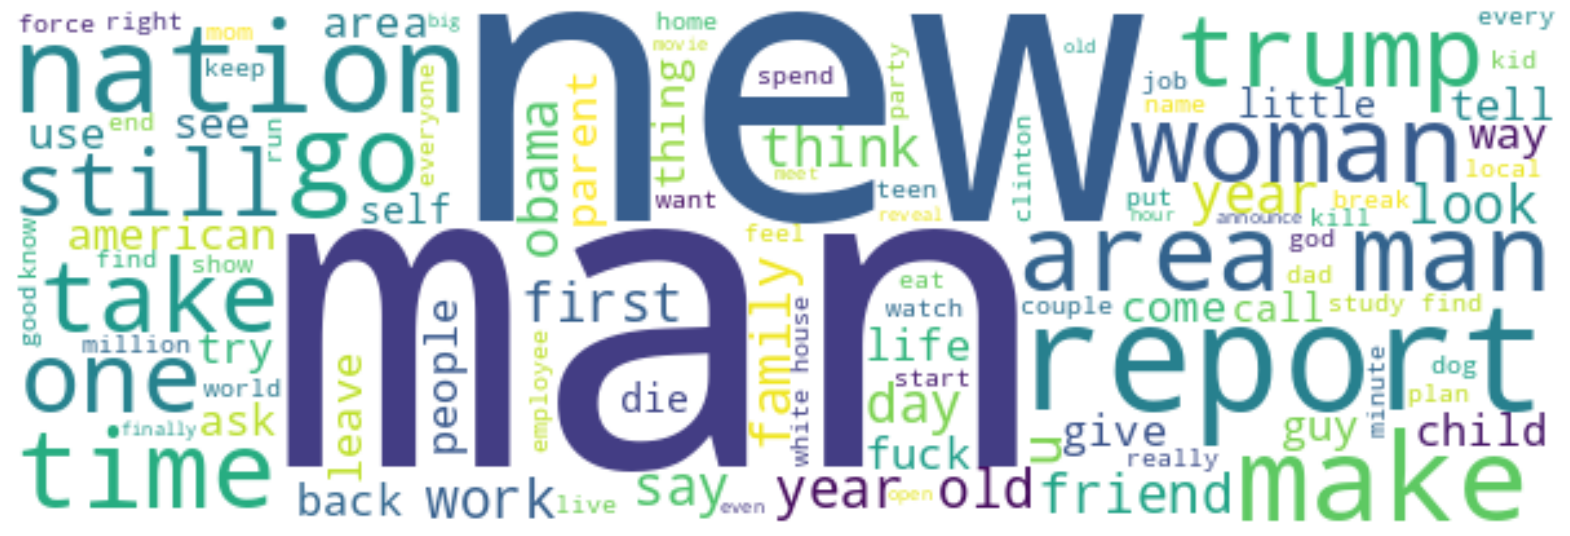

In [27]:
wordcloud = WordCloud(max_words=100, width=600, background_color='white').generate(" ".join(sarcastic_sentences))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

**Top 100 Words: Genuine Headlines**


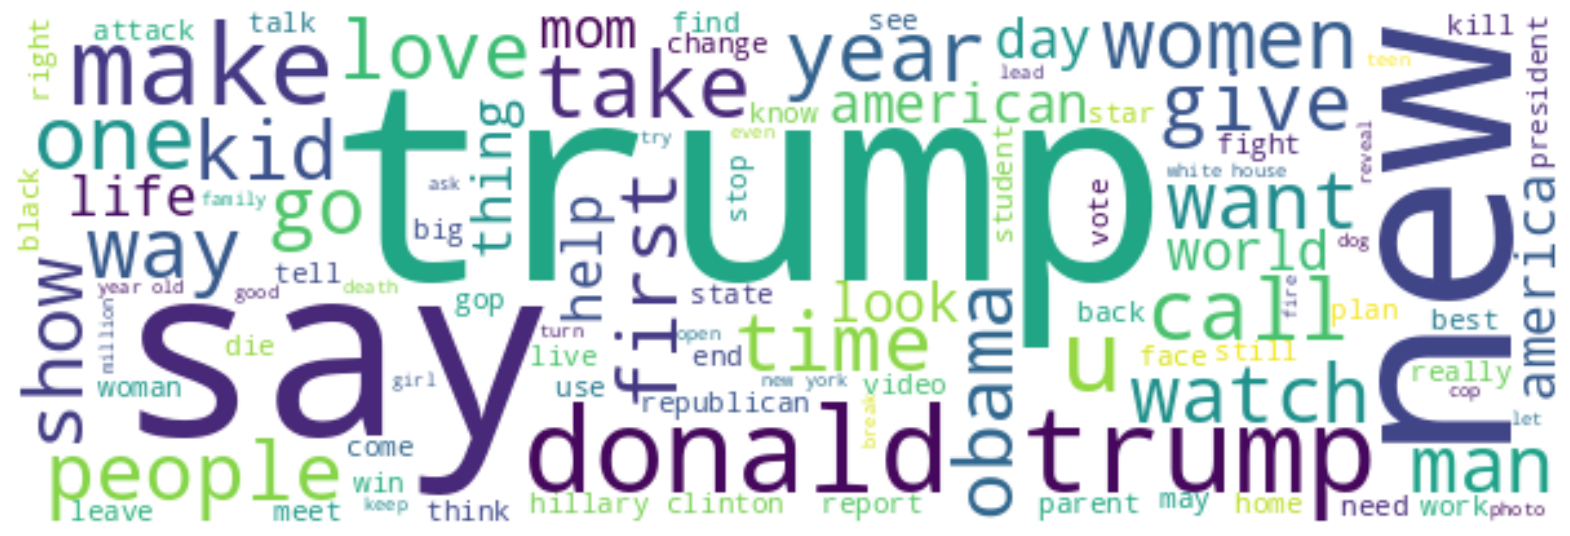

In [28]:
wordcloud = WordCloud(max_words=100, width=600, background_color='white').generate(" ".join(genuine_sentences))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Model Building

In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers
from tensorflow.keras.layers import Embedding, Layer, Dense, Dropout, MultiHeadAttention, LayerNormalization, Input, GlobalAveragePooling1D
from tensorflow.keras.layers import LSTM, Bidirectional
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

In [30]:
sentences = data['clean_headline']
label = data['is_sarcastic']

## Train - Validation - Test Splitting (80:10:10)

In [31]:
X_train, X_val, y_train, y_val = train_test_split(sentences, label, test_size=0.2, stratify=label, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, stratify=y_val, random_state=42)

## Tokenization & Padding


In [32]:
# Tokenization and padding parameters
vocab_size = 10000
oov_token = "<OOV>"
max_length = 20
trunc_type = 'post'
padding_type = 'post'

In [33]:
# Tokenize the texts
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(X_train)

In [34]:
# Convert texts to sequences
train_sequences = tokenizer.texts_to_sequences(X_train)
val_sequences = tokenizer.texts_to_sequences(X_val)
test_sequences = tokenizer.texts_to_sequences(X_test)
train_sequences

[[88, 1445, 569, 2112, 1026, 165, 4328, 8155],
 [1913, 302, 3, 493, 3659, 1568, 1, 8156, 1636],
 [2314, 3357, 249, 5793, 431],
 [15, 49, 12, 25, 56, 15, 49, 12, 25, 56],
 [42, 680, 92, 2, 83],
 [317, 3358, 214, 141, 177, 12],
 [3090, 3091, 524, 4055, 86, 1, 5, 784],
 [795, 5794, 1446, 2568, 1380, 402, 570, 558, 5],
 [122, 968, 950, 20, 2, 2659, 715, 3660],
 [3821, 196, 849, 1825, 1, 3359, 254, 138, 12],
 [2971, 4056, 1074, 5795, 1, 986, 449, 87, 75, 1],
 [642, 806, 5796, 1058, 2972],
 [306, 106, 340, 1869, 1770, 3498, 1380, 402],
 [1676, 8157, 681, 3222, 84, 552, 1177, 921, 951],
 [231, 726, 318, 1602, 146, 35, 531],
 [101, 226, 32, 3822, 82, 607],
 [4940, 360, 249, 7220, 261, 1300, 415],
 [4602, 9855, 1157, 670, 70, 2481, 532, 285, 2762],
 [1, 133, 3, 987, 637, 5297, 3223, 8158, 545],
 [671, 9856, 546, 1603, 327, 360, 3823, 3661, 327],
 [1301, 1302, 8159, 2012, 1826, 890, 1447, 768, 341],
 [579, 3360, 1569, 3662, 2113, 820, 387, 7],
 [1380, 402, 1410, 7221, 1511, 261, 4941],
 [861, 12

In [35]:
# Pad sequences to have consistent length
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)
val_padded = pad_sequences(val_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)
train_padded.tolist()

[[88,
  1445,
  569,
  2112,
  1026,
  165,
  4328,
  8155,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [1913,
  302,
  3,
  493,
  3659,
  1568,
  1,
  8156,
  1636,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [2314, 3357, 249, 5793, 431, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [15, 49, 12, 25, 56, 15, 49, 12, 25, 56, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [42, 680, 92, 2, 83, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [317, 3358, 214, 141, 177, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [3090, 3091, 524, 4055, 86, 1, 5, 784, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [795,
  5794,
  1446,
  2568,
  1380,
  402,
  570,
  558,
  5,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [122, 968, 950, 20, 2, 2659, 715, 3660, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [3821,
  196,
  849,
  1825,
  1,
  3359,
  254,
  138,
  12,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 [2971,
  4056,
  1074,
  5795,
  1,
  986,
  449,
  87,
  75,
  1,
  0,

In [37]:
X_train = train_padded
X_val = val_padded
X_test = test_padded

## Building the Transformer Encoder Block

###  Multi-Head Self-Attention Layer

In [38]:
class MultiHeadSelfAttention(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads=8):
        super(MultiHeadSelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        assert embed_dim % num_heads == 0
        self.projection_dim = embed_dim // num_heads
        self.query_dense = tf.keras.layers.Dense(embed_dim)
        self.key_dense = tf.keras.layers.Dense(embed_dim)
        self.value_dense = tf.keras.layers.Dense(embed_dim)
        self.combine_heads = tf.keras.layers.Dense(embed_dim)

    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output, weights

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)
        attention, weights = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        output = self.combine_heads(concat_attention)
        return output, weights



### Transformer Encoder Block

In [39]:
class TransformerEncoderBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerEncoderBlock, self).__init__()
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(embed_dim)
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training):
        attn_output, _ = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        return out2



### Assembling the model

In [41]:
# Hyperparameters for the Transformer encoder block
num_heads = 2
ff_dim = 32
embedding_dim = 32

# Input for the model
inputs = tf.keras.layers.Input(shape=(max_length,), dtype=tf.int32)

# Embedding layer
embedding_layer = tf.keras.layers.Embedding(vocab_size, embedding_dim)(inputs)

# Transformer Encoder Block
transformer_block = TransformerEncoderBlock(embedding_dim, num_heads, ff_dim)
encoder_output = transformer_block(embedding_layer)

# Global average pooling
pooling_layer = tf.keras.layers.GlobalAveragePooling1D()(encoder_output)

# Dense layer for classification
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(pooling_layer)

# Model
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Print the model summary
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 20)]              0         
                                                                 
 embedding (Embedding)       (None, 20, 32)            320000    
                                                                 
 transformer_encoder_block   (None, 20, 32)            6464      
 (TransformerEncoderBlock)                                       
                                                                 
 global_average_pooling1d (  (None, 32)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense_6 (Dense)             (None, 1)                 33        
                                                                 
Total params: 326497 (1.25 MB)
Trainable params: 326497 (1.25

# Train the model

In [42]:
# Train the model
num_epochs = 50

# Add earlystopping to prevent overfitting
earlystopping = EarlyStopping(monitor='val_loss', patience=1, verbose=1, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), verbose=2, callbacks=[earlystopping])

Epoch 1/50
1384/1384 - 20s - loss: 0.4189 - accuracy: 0.8035 - val_loss: 0.3477 - val_accuracy: 0.8424 - 20s/epoch - 14ms/step
Epoch 2/50
1384/1384 - 16s - loss: 0.2679 - accuracy: 0.8875 - val_loss: 0.2927 - val_accuracy: 0.8710 - 16s/epoch - 12ms/step
Epoch 3/50
1384/1384 - 16s - loss: 0.1878 - accuracy: 0.9230 - val_loss: 0.2492 - val_accuracy: 0.9035 - 16s/epoch - 12ms/step
Epoch 4/50
1384/1384 - 17s - loss: 0.1201 - accuracy: 0.9521 - val_loss: 0.2456 - val_accuracy: 0.9210 - 17s/epoch - 12ms/step
Epoch 5/50
1384/1384 - 17s - loss: 0.0756 - accuracy: 0.9720 - val_loss: 0.2432 - val_accuracy: 0.9340 - 17s/epoch - 12ms/step
Epoch 6/50
Restoring model weights from the end of the best epoch: 5.
1384/1384 - 17s - loss: 0.0531 - accuracy: 0.9801 - val_loss: 0.2564 - val_accuracy: 0.9375 - 17s/epoch - 13ms/step
Epoch 6: early stopping


# Evaluate the Model

In [43]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Accuracy on test data: {accuracy * 100:.2f}%')

Accuracy on test data: 93.26%


## Predict a Headline

In [60]:
# Example headline
headline = "Justin Bieber's Mom Says He'll Be the 'Best Daddy Ever' on Father's Day: 'You've Always Wanted to Be a Dad'."

def preprocess_sentence(sentence, tokenizer, max_length, padding_type, trunc_type):
    sequence = tokenizer.texts_to_sequences([sentence])
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding=padding_type, truncating=trunc_type)
    return padded_sequence

# Preprocess the example headline
padded_headline = preprocess_sentence(headline, tokenizer, max_length, padding_type, trunc_type)

# Predict the probability of the example being sarcastic
predicted_prob = model.predict(padded_headline)

# Interpret the prediction
is_sarcastic = (predicted_prob > 0.5).astype("int32")

print(f'Predicted Probability: {predicted_prob[0][0]:.2f}')
print(f'Sarcastic: {is_sarcastic[0][0]}')

1/1 [==============================] - 0s 65ms/step
Predicted Probability: 1.00
Sarcastic: 1
